In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.5 MB/s eta 0:00:00


In [ ]:
import kagglehub
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time
from pathlib import Path

In [ ]:
path = kagglehub.dataset_download("yusufmurtaza01/chest-xray-pneumonia-balanced-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia-balanced-dataset' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia-balanced-dataset


In [ ]:
model = YOLO('yolo26n-cls.pt')

train_results = model.train(
    data=path,
    epochs=150,
    patience=20,
    imgsz=224,
    batch=512,
    workers=8,
    device=0,
    seed=42,
    cache=True,
    cos_lr=True,
    amp=True,
    project="runs/cls",
    name="pneumonia_yolo26n"
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=512, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/input/chest-xray-pneumonia-balanced-dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pneumonia_yolo26n-2, nbs=64, nms=False, ops

In [ ]:
best_model_path = "/content/runs/classify/runs/cls/pneumonia_yolo26n-2/weights/best.pt"

best_model = YOLO(best_model_path)

metrics = best_model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /kaggle/input/chest-xray-pneumonia-balanced-dataset/train... found 6800 images in 2 classes ✅ 
val: /kaggle/input/chest-xray-pneumonia-balanced-dataset/val... found 1700 images in 2 classes ✅ 
test: /kaggle/input/chest-xray-pneumonia-balanced-dataset/test... found 30 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.2±0.4 ms, read: 384.3±117.9 MB/s, size: 338.2 KB)
val: Scanning /kaggle/input/chest-xray-pneumonia-balanced-dataset/val... 1700 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1700/1700 3.6Kit/s 0.5s
WARNING ⚠️ val: Cache directory /kaggle/input/chest-xray-pneumonia-balanced-dataset is not writable, cache not saved.
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 107/107 40.3it/s 2.7s
                   all      0.985          1
Speed: 0.0ms preprocess, 

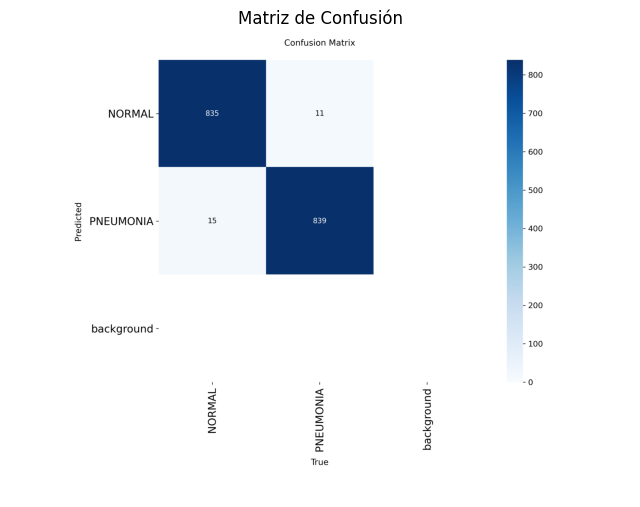

In [ ]:
image_path = '/content/runs/classify/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

In [ ]:
def evaluar_modelo_test(ruta_modelo: str, ruta_dataset_test: str) -> None:
    """
    Ejecuta inferencia sobre un conjunto de prueba clasificado en subcarpetas,
    calculando la precisión real y la latencia promedio por imagen.
    """
    model = YOLO(ruta_modelo)
    test_dir = Path(ruta_dataset_test)

    correctas = 0
    total = 0
    tiempos_inferencia = []

    print("Iniciando evaluación en conjunto de Test...\n")

    # Iterar sobre cada subcarpeta (NORMAL, PNEUMONIA)
    for class_dir in test_dir.iterdir():
        if not class_dir.is_dir():
            continue

        clase_real = class_dir.name.upper()

        # Procesar cada imagen dentro de la clase
        for img_path in class_dir.glob("*.*"):
            total += 1

            # Iniciar cronómetro para medir latencia
            start_time = time.time()

            # verbose=False evita que la consola colapse con cientos de mensajes
            resultado = model.predict(
                source=str(img_path),
                imgsz=224,
                device=0,
                verbose=False
            )[0]

            # Detener cronómetro
            end_time = time.time()
            tiempos_inferencia.append(end_time - start_time)

            # Extraer la clase predicha
            clase_predicha_idx = resultado.probs.top1
            clase_predicha_nombre = resultado.names[clase_predicha_idx].upper()

            # Evaluar acierto
            if clase_predicha_nombre == clase_real:
                correctas += 1

    # Cálculo de métricas finales
    precision = (correctas / total) * 100 if total > 0 else 0
    latencia_promedio_ms = (sum(tiempos_inferencia) / len(tiempos_inferencia)) * 1000 if tiempos_inferencia else 0

    print("-" * 30)
    print("RESULTADOS DE INFERENCIA (SIMULACIÓN EDGE)")
    print("-" * 30)
    print(f"Total de imágenes evaluadas: {total}")
    print(f"Precisión Global:            {precision:.2f}% ({correctas}/{total})")
    print(f"Latencia Promedio:           {latencia_promedio_ms:.2f} ms por imagen")
    print("-" * 30)

In [ ]:
best_model_path = "/content/runs/classify/runs/cls/pneumonia_yolo26n-2/weights/best.pt"
test_path = "/kaggle/input/chest-xray-pneumonia-balanced-dataset/test"

evaluar_modelo_test(best_model_path, test_path)

Iniciando evaluación en conjunto de Test...

------------------------------
RESULTADOS DE INFERENCIA (SIMULACIÓN EDGE)
------------------------------
Total de imágenes evaluadas: 30
Precisión Global:            100.00% (30/30)
Latencia Promedio:           19.22 ms por imagen
------------------------------


In [ ]:
ruta_pesos = "/content/runs/classify/runs/cls/pneumonia_yolo26n-2/weights/best.pt"

modelo = YOLO(ruta_pesos)

print("Iniciando exportación a ONNX...")

ruta_exportada = modelo.export(
  format="onnx",
  imgsz=224,
  half=False,       # Cuantización a FP16 (ideal para WebGL/WebGPU)
  simplify=True,   # Simplifica la arquitectura del grafo para mayor velocidad
  opset=17         # Versión del Opset altamente compatible con onnxruntime-web
)

print(f"\n¡Exportación exitosa! Descarga el archivo desde: {ruta_exportada}")

Iniciando exportación a ONNX...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (AMD EPYC 9B45)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs

PyTorch: starting from '/content/runs/classify/runs/cls/pneumonia_yolo26n-2/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 2) (3.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 205ms
Prepared 4 packages in 840ms
Installed 4 packages in 129ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.94...
ONNX: converting to FP16...
ONNX: export success ✅ 2.0s, saved as '/content/r